# 01 — Data Pipeline: Cell Universe, Node Features, Spatial & Lineage Lookup Tables

This notebook builds the foundational data structures for the DHGNN pipeline:

1. The fixed **cell universe** (every cell name -> integer index).
2. Per-timepoint **node feature matrices** `X(t)` (position, size, lineage generation, presence).
3. The **lineage lookup table** (`output_tables/lineage_lookup_table.csv`) — static parent/daughter triplets.
4. The **spatial lookup table** (`output_tables/spatial_lookup_table.csv`) — per-timepoint DBSCAN spatial communities.

Together with the pre-existing `functional_lookup_table.csv` and `anastomosis_lookup_table.csv`, `output_tables/` now contains all four hyperedge sources used to assemble `H_aug(t)` in notebook 02.

In [1]:
import os
import sys

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.cluster import DBSCAN

sys.path.insert(0, os.path.abspath('..'))

from dhgnn_lib.cell_universe import CellUniverse
from dhgnn_lib import hyperedges, node_features, visualization

RAW_DIR = '../raw_dataset'
OUTPUT_DIR = '../output_tables'


## 1. Cell universe

Sorted union of every cell name across the raw dataset and the existing lookup tables.

In [2]:
universe = CellUniverse.build(RAW_DIR, OUTPUT_DIR)
print(f'Cell universe size N = {len(universe)}')
universe.to_dataframe().head()


Cell universe size N = 1625


,index,cell,lineage_generation
0,0,AB,0
1,1,ABa,1
2,2,ABal,2
3,3,ABala,3
4,4,ABalaa,4


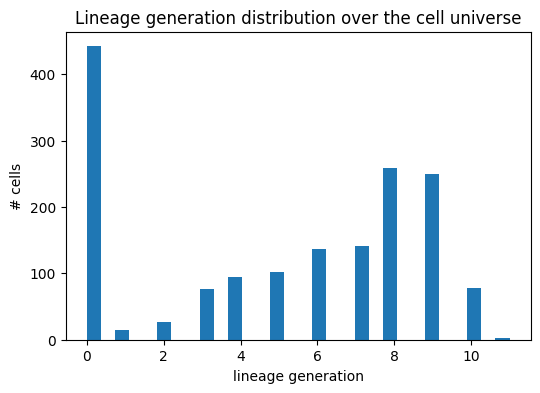

In [3]:
fig, ax = plt.subplots(figsize=(6, 4))
universe.to_dataframe()['lineage_generation'].plot.hist(bins=30, ax=ax)
ax.set_xlabel('lineage generation')
ax.set_ylabel('# cells')
ax.set_title('Lineage generation distribution over the cell universe')
plt.show()


## 2. Node features `X(t)`

For every timepoint t, build an `(N, 6)` feature matrix: `[x, y, z, size, lineage_generation, presence]` (x/y/z/size z-score normalised, lineage_generation min-max normalised, presence is a 0/1 flag).

In [4]:
nfb = node_features.NodeFeatureBuilder(RAW_DIR, universe)
print(f'Timepoints: {nfb.timepoints[0]}..{nfb.timepoints[-1]} (T={len(nfb.timepoints)})')
print(f'Feature columns: {nfb.FEATURE_NAMES}')

T_SAMPLE = 100
x = nfb.build(T_SAMPLE)
print(f'X(t={T_SAMPLE}) shape: {tuple(x.shape)}, present cells: {int(x[:, 5].sum())}')


Timepoints: 1..190 (T=190)
Feature columns: ['x', 'y', 'z', 'size', 'lineage_generation', 'presence']
X(t=100) shape: (1625, 6), present cells: 317


### Visualize cell positions in 3D at a sample timepoint

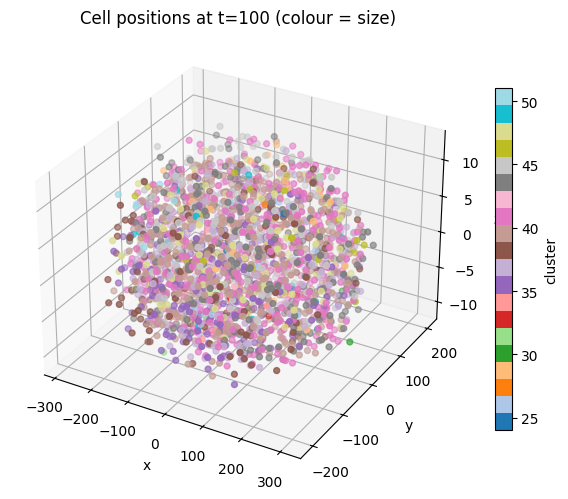

In [5]:
pos = nfb.raw_positions(T_SAMPLE)
fig = visualization.plot_cell_positions_3d(pos, color=pos['size'], title=f'Cell positions at t={T_SAMPLE} (colour = size)')
plt.show()


## 3. Lineage lookup table

Each row of `cells_birth_and_pos.csv` (`{Parent Cell, Daughter 1, Daughter 2}`) becomes one static 3-node hyperedge with weight 1.0. Written to `output_tables/lineage_lookup_table.csv`.

In [18]:
lineage_df = hyperedges.save_lineage_lookup_table(RAW_DIR, OUTPUT_DIR)
print(f'lineage_lookup_table.csv: {len(lineage_df)} rows -> {OUTPUT_DIR}/lineage_lookup_table.csv')
lineage_df.head()


lineage_lookup_table.csv: 642 rows -> ../output_tables/lineage_lookup_table.csv


,hyperedge_id,parent_cell,daughter_1,daughter_2,members,birth_time,parent_x,parent_y,parent_z,hyperedge_weight
0,LIN_0000,P0,AB,P1,P0|AB|P1,0,422.077778,248.316667,14.326667,1.0
1,LIN_0001,AB,ABa,ABp,AB|ABa|ABp,17,317.785054,251.800426,14.700365,1.0
2,LIN_0002,P1,EMS,P2,P1|EMS|P2,18,445.339357,253.860563,15.238196,1.0
3,LIN_0003,ABa,ABar,ABal,ABa|ABar|ABal,35,251.150370,254.408363,15.063837,1.0
4,LIN_0004,ABp,ABpr,ABpl,ABp|ABpr|ABpl,35,358.984127,267.276513,14.877588,1.0


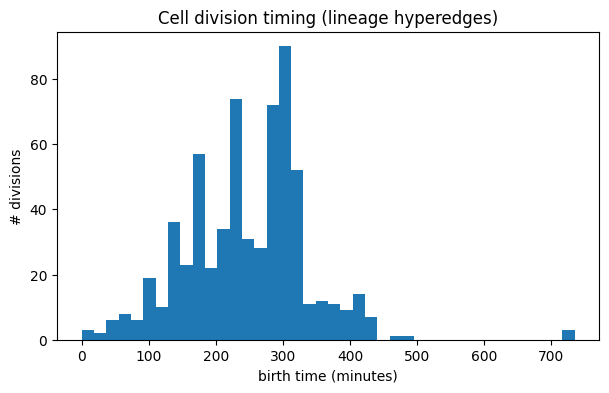

In [19]:
fig, ax = plt.subplots(figsize=(7, 4))
lineage_df['birth_time'].plot.hist(bins=40, ax=ax)
ax.set_xlabel('birth time (minutes)')
ax.set_ylabel('# divisions')
ax.set_title('Cell division timing (lineage hyperedges)')
plt.show()


## 4. Spatial lookup table

For every timepoint, run `DBSCAN(eps=15, min_samples=3)` on `(x, y, z)` cell positions from `ce_temporal_data.csv`. Each non-noise cluster becomes one spatial hyperedge. Written to `output_tables/spatial_lookup_table.csv`.

In [20]:
spatial_df = hyperedges.save_spatial_lookup_table(RAW_DIR, OUTPUT_DIR)
print(f'spatial_lookup_table.csv: {len(spatial_df)} rows across {spatial_df["t"].nunique()} timepoints')
print(f'-> {OUTPUT_DIR}/spatial_lookup_table.csv')
spatial_df.head()


spatial_lookup_table.csv: 5336 rows across 146 timepoints
-> ../output_tables/spatial_lookup_table.csv


,hyperedge_id,t,cluster_id,members,cluster_size,hyperedge_weight
0,SPA_000000,15,0,ABal|ABar|Cp,3,1.0
1,SPA_000001,30,0,ABplp|Ca|Caa,3,1.0
2,SPA_000002,38,0,ABpra|ABarapp|ABplpa,3,1.0
3,SPA_000003,40,0,ABpla|ABprpap|Cpa,3,1.0
4,SPA_000004,42,0,ABplpp|ABarppp|ABpraap,3,1.0


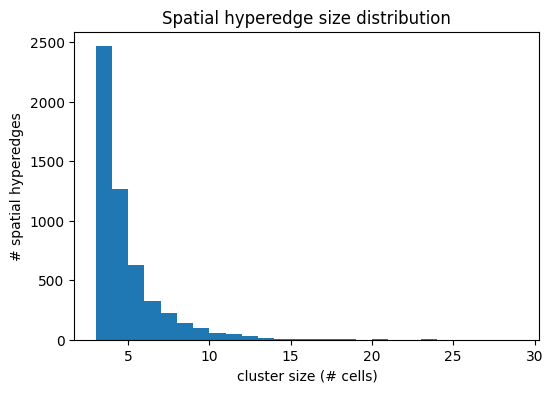

In [21]:
fig, ax = plt.subplots(figsize=(6, 4))
spatial_df['cluster_size'].plot.hist(bins=range(3, int(spatial_df['cluster_size'].max()) + 2), ax=ax)
ax.set_xlabel('cluster size (# cells)')
ax.set_ylabel('# spatial hyperedges')
ax.set_title('Spatial hyperedge size distribution')
plt.show()


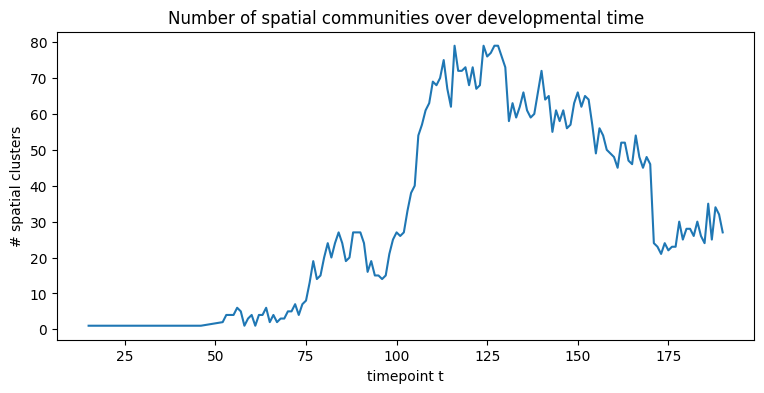

In [22]:
fig, ax = plt.subplots(figsize=(9, 4))
spatial_df.groupby('t').size().plot(ax=ax)
ax.set_xlabel('timepoint t')
ax.set_ylabel('# spatial clusters')
ax.set_title('Number of spatial communities over developmental time')
plt.show()


### Visualize DBSCAN clusters at the sample timepoint

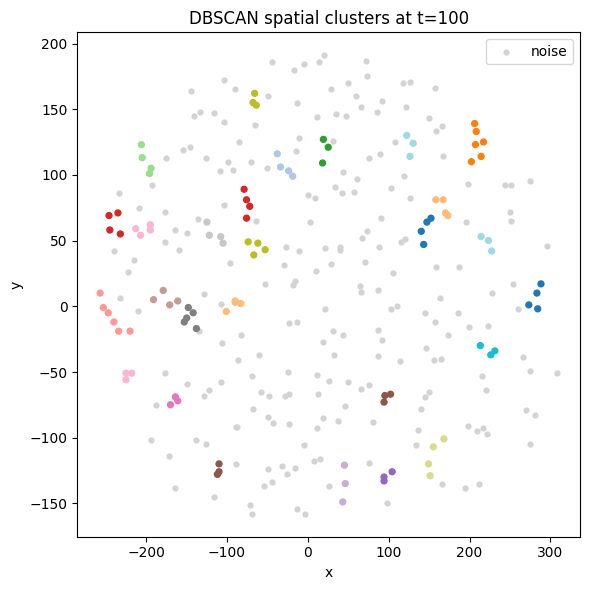

102 of 317 cells assigned to 27 clusters


In [23]:
ctd = pd.read_csv(os.path.join(RAW_DIR, 'ce_temporal_data.csv'))
frame_t = ctd[ctd['time'] == T_SAMPLE].drop_duplicates('cell').reset_index(drop=True)
coords = frame_t[['x', 'y', 'z']].to_numpy()
cluster_labels = DBSCAN(eps=hyperedges.SPATIAL_EPS, min_samples=hyperedges.SPATIAL_MIN_SAMPLES).fit_predict(coords)

fig = visualization.plot_dbscan_clusters(frame_t, cluster_labels, title=f'DBSCAN spatial clusters at t={T_SAMPLE}')
plt.show()
print(f'{(cluster_labels != -1).sum()} of {len(cluster_labels)} cells assigned to '
      f'{len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)} clusters')


## Summary

- `output_tables/` now contains **4 lookup tables**: `lineage_lookup_table.csv` (new), `spatial_lookup_table.csv` (new), `functional_lookup_table.csv`, `anastomosis_lookup_table.csv`.
- The cell universe (`N` cells) and per-timepoint node features `X(t)` are ready.
- Next: **notebook 02** assembles these four sources into the `H_aug(t)` incidence matrix.